In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
# JAX will sometimes print a warning about not finding a cuda device when it is first imported or run. 
# Don't worry, it will default to CPU

import jax
import jax.numpy as jnp
import optax
import equinox as eqx
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm, trange


# We'll reuse these functions from the last notebook. 
# Added 'keys' args. You'll see why they are needed in the next block.
@eqx.filter_jit 
def make_step(model, x, y, keys, opt_state, optim):
    loss, grads = loss_fn(model, x, y, keys)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, grads, model, opt_state

@eqx.filter_value_and_grad
def loss_fn(model, x, y, keys):
    pred_y = jax.vmap(model)(x, keys)
    return jax.numpy.mean((y - pred_y) ** 2) 

# Creating a model in equinox
In the last notebook, we just used the `Linear` layer defined by equinox. Building exactly the model we want takes some more effort. Equinox allows us to do this by creating implementations of the `equinox.Module` class. These must have at least two methods: `__init__` and `__call__`. As their names imply, `init` is used to make a new instance of the model, and `call` is invoked when you call a specific instance of that model. These methods are normally used implicitly in python so you might not be familiar, but they are used explicitly like this:

```python
model_instance = Model_Class(args) # implicit init
model_instance = Model_Class.__init__(args) # explicit equivalent

predicitons = model_instance(data) # implicit call
predicitons = model_instance._call__(data) # explicit equivalent

```

The `call` method is the **forward** pass of the model so it takes in some data and returns your predictions. You can also return other data (often I'll return some internal weights so I can plot them), but you will need to calculate a loss based on at least part of the return in order to create the gradients for training. 

## LSTM model

In this example we create a fairly standard LSTM model. It combines 3 layers from equinox: `LSTMCell`, `MLP`, and `Dropout`. These are all standard DL layers, and [documented in equinox](https://docs.kidger.site/equinox/api/nn/rnn/#equinox.nn.LSTMCell). The trickiest thing in this example is the the use of `jax.lax.scan` which is [like a regular python loop but is optimized](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html) for compilation on accelerated hardware. This scan concept is very useful time series modeling when you have a state or memory that evolves, as the output is automatically input into the next iteration. So we start an initial state `init_state` that is all 0s. This state evolves in each time step of the model and then is finally used for predicitons at the end. 

In [2]:
from jaxtyping import Array, PRNGKeyArray

class LSTM_MLP(eqx.Module):
    """LSTM model with dropout and an MLP regression head"""
    # All class attributes must added here before init
    cell: eqx.nn.LSTMCell
    head: eqx.nn.MLP
    dropout: eqx.nn.Dropout

    def __init__(self, in_size: int, hidden_size: int, out_size: int, dropout_rate: float, *, key: PRNGKeyArray):
        k1, k2 = jax.random.split(key)
        
        self.cell = eqx.nn.LSTMCell(in_size, hidden_size, key=k1)
        self.head = eqx.nn.MLP(hidden_size, out_size, width_size=hidden_size*2, depth=2, key=k2)
        self.dropout = eqx.nn.Dropout(dropout_rate)

    def __call__(self, x, key):
        # initial (h, c)
        init_state = (jnp.zeros(self.cell.hidden_size),
                      jnp.zeros(self.cell.hidden_size))

        def scan_fn(state, scan_x):
            h_new, c_new = self.cell(scan_x, state)
            return (h_new, c_new), h_new
        
        # jax.lax.scan is essentially a for loop with a carry forward mechanism.
        # It start with the initial state and iterates over the first dimension of x
        # Here, this first dimension should be time. The initial state evolves by the logic
        # of the LSTM, and at the end we are left with the final h,c states as well as the 
        # full accumulated series of h states. We won't use the accumulated states now. 
        (h_final, c_final), h_accum = jax.lax.scan(scan_fn, init_state, x)

        # Apply the dropout. After training there's a trick for turning this off.
        h_accum = self.dropout(h_accum, key=key)

        # make the final head prediciton based on the final states.
        pred = jax.vmap(self.head)(h_accum)

        # We'll print out the shapes of the important arrays in our model to help understand.
        # Remember though that this model will be called after `vmap`ing over the batch dimension.
        
        # It's actually not a big deal to leave print statements in your models, as they will only
        # execute when the model is ran the first time during JIT compilation. It won't 
        # spam the output or log files if properly JIT'd. Notice it doesn't print in this block though,
        # as we are only calling the `init` method when we create a model.
        print(f"{x.shape = }")
        print(f"{init_state[0].shape = }")
        print(f"{init_state[1].shape = }")
        print(f"{h_accum.shape = }")
        print(f"{pred.shape = }")

        return pred

in_size = 3 # P, ET, dS
hidden_size = 16
out_size = 1
dropout_rate = 0.3
key = jax.random.PRNGKey(0)

model = LSTM_MLP(in_size, hidden_size, out_size, dropout_rate, key=key)
# Print the model out to see all it's attributes and layer sizes.
model

ERROR:2026-04-16 13:21:16,824:jax._src.xla_bridge:502: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/tlanghorst_umass_edu/.local/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 500, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/tlanghorst_umass_edu/.local/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tlanghorst_umass_edu/.local/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


LSTM_MLP(
  cell=LSTMCell(
    weight_ih=f32[64,3],
    weight_hh=f32[64,16],
    bias=f32[64],
    input_size=3,
    hidden_size=16,
    use_bias=True
  ),
  head=MLP(
    layers=(
      Linear(
        weight=f32[32,16],
        bias=f32[32],
        in_features=16,
        out_features=32,
        use_bias=True
      ),
      Linear(
        weight=f32[32,32],
        bias=f32[32],
        in_features=32,
        out_features=32,
        use_bias=True
      ),
      Linear(
        weight=f32[1,32],
        bias=f32[1],
        in_features=32,
        out_features=1,
        use_bias=True
      )
    ),
    activation=<PjitFunction of <function relu at 0x7bf2782d0c20>>,
    final_activation=<function <lambda>>,
    use_bias=True,
    use_final_bias=True,
    in_size=16,
    out_size=1,
    width_size=32,
    depth=2
  ),
  dropout=Dropout(p=0.3, inference=False)
)

## Model object
printing our new model shows all of its components (including those inhereted from the `eqx.module` class). You can also see the sizes of arrays for each component of the model. The other important thing about this model is that it contains both **trainable** and **non-trainable** values. For example, the LSTMCell has a vector of `bias` parameters that will be updated based on the gradients and optimizer. The LSTMCell also has a boolean attribute `use_bias` which will obviously not be updated! 

**The optimizer will attempt to update any values that jax arrays during training.** So if you need to add an attribute during `__init__` to keep track of some static value, like `ensemble_number`, that should be a regular python `int`. Equinox also provides [convenient methods for filtering models](https://docs.kidger.site/equinox/api/transformations/) into these trainable and static components. You might notice the `make_step` function at the top of this notebook has the decorator `@eqx.filter_jit`, whereas it has only `@jax.jit` in the previous notebook. This means only the differentiable part of the model is passed into the JIT.

In [3]:
model.cell

LSTMCell(
  weight_ih=f32[64,3],
  weight_hh=f32[64,16],
  bias=f32[64],
  input_size=3,
  hidden_size=16,
  use_bias=True
)

# Data model

The next two blocks set up a function for creating new input data and a `true_model` for making target data from those inputs. This is similar to the previous example of the `Linear` model, except we want to make the true model more complicated to match the abilities of an LSTM model. I won't exaplain it, since it's a very silly, hand-wavy, hydrological-ish model. But, the important thing is that it has non-linearities and a system memory that evolves based on the order of inputs. 

I used `jax.numpy` for all of this data creation just to show off its use and especially the `jax.lax.scan` funtionality again. I could have used regular numpy (or loaded the data from disk!) and just converted them to jax arrays in the end using `x = jnp.Array(x)`. Just like the trainable model parameters, the inputs and outputs need to be jax arrays in order for the gradient tracing to work. You'll get a loud error from jax if they aren't so don't worry about missing this. 

In [4]:
sequence_length = 90
batch_size = 64

def get_input(k):
    # Again, notice we need to explicitly pass and use RNG keys with jax
    feat_shape = (batch_size, sequence_length, in_size)
    x = jax.random.normal(k, feat_shape)
    return x

key, data_key = jax.random.split(key)

x = get_input(key)
print(x.shape)

(64, 90, 3)


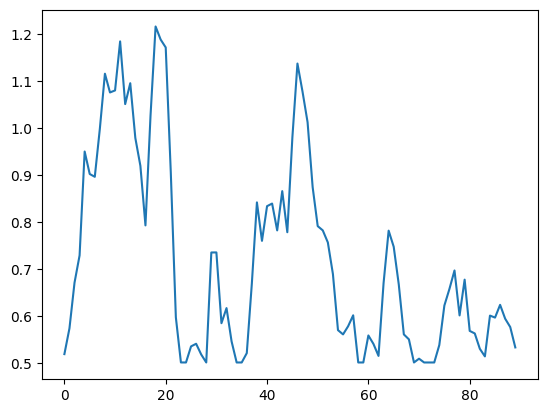

In [5]:
def true_model(x):
    def storage_step(storage, inputs):
        precip, et, ds = inputs
        
        # Bias net flux to be positive on average and reduce ET impact
        net_flux = jnp.abs(precip) - jnp.abs(et) + ds + 0.1
        
        # Update storage with a small floor to make it positive and non 0
        temp_storage = jnp.maximum(0.05, storage + net_flux)
    
        # Calculate runoff using non-linear power law + baseflow
        k = 0.005 # Recession constant
        alpha = 1.2 
        baseflow = 0.05 # Constant minimum discharge
        runoff = k * jnp.power(temp_storage, alpha) + baseflow
        
        # Update carry for next step
        next_storage = jnp.maximum(0.0, temp_storage - runoff)
        
        # Return (carry, output). We put both values in output to get full series.
        return next_storage, (next_storage, runoff)

    
    def scan_fn(xs):
        # Initial carry must be a float to match computation types
        # lax.scan returns: (final_carry, stacked_outputs)
        _, (storage_history, runoff_history) = jax.lax.scan(storage_step, 1.0, xs)
        return storage_history, runoff_history

    # x shape: (batch, seq_len, in_size)
    # vmap over the batch dimension (axis 0)
    storage_batch, runoff_batch = jax.vmap(scan_fn)(x)
    
    return runoff_batch * 10 # Very klugey but quick rescaling for numerical stability.

runoff = true_model(x)

plt.plot(runoff[0,:]) # plot one sequence of runoff. Doesn't look great but it will work.

In [6]:
# Test model forward call and see the model dimensions.
key, model_key = jax.random.split(key)
batch_keys = jax.random.split(model_key, batch_size) # each entry in batch needs a key

batch_pred = jax.vmap(model)(x, batch_keys)
print(f"{batch_pred.shape = }")

x.shape = (90, 3)
init_state[0].shape = (16,)
init_state[1].shape = (16,)
h_accum.shape = (90, 16)
pred.shape = (90, 1)
batch_pred.shape = (64, 90, 1)


# Training

Nearly identical to the `Linear` model example at this stage. Only addition is adding in the batch_keys splitting for use in the dropout layer. We also regenerate new data for every step.

  0%|          | 0/500 [00:00<?, ?it/s]

x.shape = (90, 3)
init_state[0].shape = (16,)
init_state[1].shape = (16,)
h_accum.shape = (90, 16)
pred.shape = (90, 1)


100%|██████████| 500/500 [01:09<00:00,  7.19it/s]


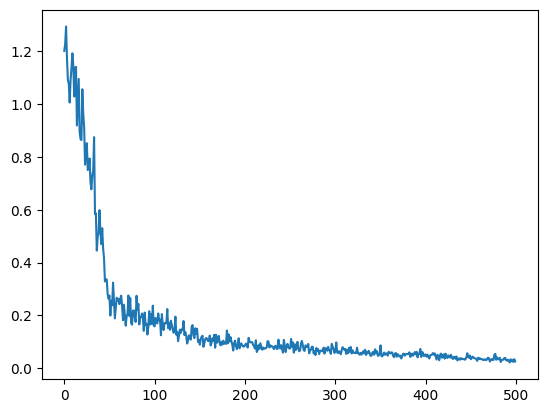

In [7]:
max_iter = 500
learning_rate = 0.001

# Let's start with a fresh model
key = jax.random.PRNGKey(0)
key, model_key = jax.random.split(key)
model = LSTM_MLP(in_size, hidden_size, out_size, dropout_rate, key=key)

optim = optax.adam(learning_rate)
opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

# # training loop.
losses = []
grad_norms = []
for step in trange(1, max_iter+1):
    key, data_key, model_key = jax.random.split(key, 3)
    batch_keys = jax.random.split(model_key, batch_size)
    
    x = get_input(data_key)
    y = true_model(x)[...,jnp.newaxis] # Add an 'n_feature' dimension to the obs.
    
    loss, grads, model, opt_state = make_step(model, x, y, batch_keys, opt_state, optim)
    losses.append(loss)
    grad_norms.append(optax.global_norm(grads))

plt.plot(losses)


In [8]:
model.dropout

Dropout(p=0.3, inference=False)

## Testing the model
We'll just do a jax.vmap of the model over the batch dimension for our first predicitons. Importantly, this still uses the dropout layer. To turn off dropout, we use a function from equinox `eqx.nn.inference_mode` which looks for any attributes anywhere in the model named `inference` and sets it to True (or False if you add an argument). The `eqx.nn.Dropout` layer has logic built in to not do anything if this attribute is True. 

In [9]:
batch_pred = jax.vmap(model)(x, batch_keys)

inference_model = eqx.nn.inference_mode(model)
batch_inf = jax.vmap(inference_model)(x, batch_keys)

x.shape = (90, 3)
init_state[0].shape = (16,)
init_state[1].shape = (16,)
h_accum.shape = (90, 16)
pred.shape = (90, 1)
x.shape = (90, 3)
init_state[0].shape = (16,)
init_state[1].shape = (16,)
h_accum.shape = (90, 16)
pred.shape = (90, 1)


In [10]:
# Can inspect the dropout layers to see the change
print(f"{model.dropout = }")
print(f"{inference_model.dropout = }")

model.dropout = Dropout(p=0.3, inference=False)
inference_model.dropout = Dropout(p=0.3, inference=True)


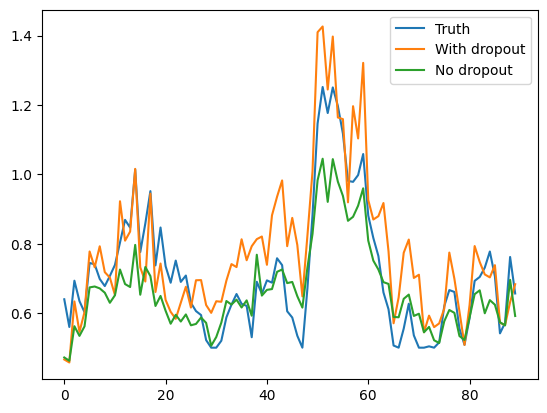

In [11]:
# Now just plot a set of the model runs with and without dropout.
plot_idx = 1 # batch index. 

plt.plot(y[plot_idx,:,0], label='Truth')
plt.plot(batch_pred[plot_idx,:,0], label='With dropout')
plt.plot(batch_inf[plot_idx,:,0], label='No dropout')
plt.legend()

# It actually is making things worse in this case. 
# This is probably because our model is way too powerful (too many parameters for the complexity of the problem), 
# and simple data and training scheme (relatively simple true system with no noise and the exact same distribution for training/testing).

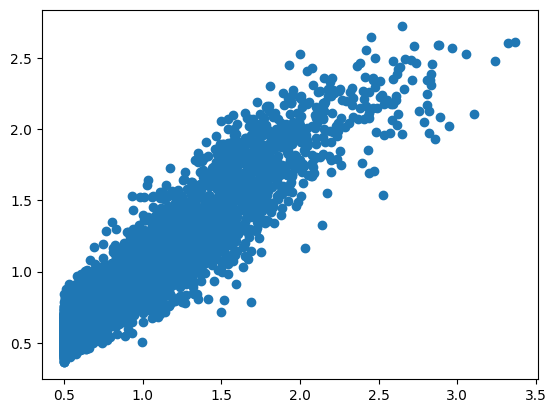

In [12]:
plt.scatter(y, batch_pred)